# タクシー乗車の探索分析 — v020-exp-23

Kaggle参照: https://www.kaggle.com/datasets?search=nyc+taxi+trips

## 分析計画（取得前）
公開候補をAPIで検索し、距離・乗降時刻・運賃・チップ・支払方法がそろう小規模ファイルを優先する。ファイル全行を探索対象にし、大規模なら取得後に明示した固定シード標本へ切り替える。原データの件数・欠損・重複・分位点と、時刻逆転、ゼロ距離、負の金額、速度、金額内訳整合性を調べる。中央値・分位点、Pearson/Spearman相関、密度図、支払方法別のチップを使う。料金とチップの単なる金額関係と、チップ率の関係を分ける。外れ値の除外は別標本として行い、原標本を残して感度を検証する。因果推論は行わない。

実行はJupyter MCPのみ。取得データはdata_dirに保存し、トークン・SDKログ・認証例外本文は出力しない。Notebook本文の構築はenqueue_write、実行出力はJupyter MCPが保存する。

In [1]:
from pathlib import Path
import os, sys, json, io, contextlib, hashlib, zipfile, warnings
from datetime import datetime, timezone
from dataclasses import asdict
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display
from ai_data_scientist import project_manager as pm, lifecycle, language_router
RUN_ID = 'v020-exp-23'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-23-taxis')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
def log_phase(event):
    phase_log.append({'time_utc': datetime.now(timezone.utc).isoformat(), 'event': event})
def begin_execution(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行の中止要求を受信しました')
    lifecycle.mark_execution_start(RUN_ID)
    log_phase('execution_start:' + name)
def end_execution(name):
    lifecycle.mark_execution_end(RUN_ID)
    log_phase('execution_end:' + name)
def write_notebook(mutation):
    lifecycle.mark_write_start(RUN_ID)
    log_phase('write_start')
    try:
        pm.enqueue_write(handle, mutation)
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_write_end(RUN_ID)
        log_phase('write_end')
print({'run_id': RUN_ID, 'language': language_router.detect_language('タクシーの乗車データを分析してください'), 'notebook': str(handle.notebook_path)})


{'run_id': 'v020-exp-23', 'language': 'ja', 'notebook': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-23-taxis/notebooks/kaggle-v020-kaggle-exp-23-taxis.ipynb'}


# Kaggle API検索記録

In [2]:
begin_execution('kaggle_search')
api_failures = []
kaggle_candidates = []
kaggle_files = []
api = None
def safe_api_failure(stage, exc):
    status = getattr(getattr(exc, 'response', None), 'status_code', None)
    record = {'stage': stage, 'exception_class': type(exc).__name__, 'http_status': status,
              'detail': '秘密情報保護のため例外本文・SDKログは出力しない'}
    api_failures.append(record)
    print(record)
try:
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        print('KaggleApi().authenticate(): success')
    except (Exception, SystemExit) as exc:
        safe_api_failure('KaggleApi().authenticate()', exc)
    if api is not None and not api_failures:
        for query in ['seaborn taxis', 'nyc taxi trips', 'taxi tips']:
            try:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    found = api.dataset_list(search=query, page=1)
                candidates = [{'search': query, 'ref': x.ref, 'title': x.title,
                               'total_bytes': getattr(x, 'totalBytes', None)} for x in found[:8]]
                kaggle_candidates.extend(candidates)
                print(json.dumps(candidates, ensure_ascii=False))
            except Exception as exc:
                safe_api_failure('dataset_list(search=' + query + ')', exc)
        refs = list(dict.fromkeys(x['ref'] for x in kaggle_candidates))
        for ref in refs[:12]:
            try:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    listing = api.dataset_list_files(ref)
                entries = getattr(listing, 'files', getattr(listing, 'dataset_files', []))
                records = [{'ref': ref, 'filename': f.name, 'bytes': getattr(f, 'totalBytes', getattr(f, 'total_bytes', None))} for f in entries]
                kaggle_files.extend(records)
                print(json.dumps(records, ensure_ascii=False))
            except Exception as exc:
                safe_api_failure('dataset_list_files(' + ref + ')', exc)
finally:
    end_execution('kaggle_search')
display(pd.DataFrame(kaggle_files))


KaggleApi().authenticate(): success
[{"search": "seaborn taxis", "ref": "abdmental01/taxis-dataset-yellow-taxi", "title": "Taxis Dataset | Yellow Taxi | Cleaned Version |", "total_bytes": null}, {"search": "seaborn taxis", "ref": "abdoomoh/all-seaborn-built-in-datasets", "title": "All Seaborn Built-in Datasets 📊✨", "total_bytes": null}]
[{"search": "nyc taxi trips", "ref": "fivethirtyeight/uber-pickups-in-new-york-city", "title": "Uber Pickups in New York City", "total_bytes": null}, {"search": "nyc taxi trips", "ref": "shuhengmo/uber-nyc-forhire-vehicles-trip-data-2021", "title": "Uber NYC for-hire vehicles trip data (2021)", "total_bytes": null}, {"search": "nyc taxi trips", "ref": "elemento/nyc-yellow-taxi-trip-data", "title": "NYC Yellow Taxi Trip Data", "total_bytes": null}, {"search": "nyc taxi trips", "ref": "nagasai524/nyc-taxi-trip-records-from-jan-2023-to-jun-2023", "title": "NYC Taxi Trip Records from JAN 2023 to JUN 2023", "total_bytes": null}, {"search": "nyc taxi trips", 

,ref,filename,bytes
0,abdmental01/taxis-dataset-yellow-taxi,taxis_cleaned.csv,867788
1,abdoomoh/all-seaborn-built-in-datasets,Seaborn All Built-in Datasets/anagrams.csv,420
2,abdoomoh/all-seaborn-built-in-datasets,Seaborn All Built-in Datasets/anscombe.csv,601
3,abdoomoh/all-seaborn-built-in-datasets,Seaborn All Built-in Datasets/attention.csv,1269
4,abdoomoh/all-seaborn-built-in-datasets,Seaborn All Built-in Datasets/brain_networks.csv,1076925
...,...,...,...
86,microize/newyork-yellow-taxi-trip-data-2020-2019,yellow_tripdata_2019-09.csv,608973500
87,microize/newyork-yellow-taxi-trip-data-2020-2019,yellow_tripdata_2019-10.csv,669168416
88,microize/newyork-yellow-taxi-trip-data-2020-2019,yellow_tripdata_2019-11.csv,637807959
89,microize/newyork-yellow-taxi-trip-data-2020-2019,yellow_tripdata_2019-12.csv,639108129


# 取得ファイルと来歴

Seaborn組み込みデータ集のtaxis.csvを選ぶ。小規模で乗降時刻・距離・運賃・チップ・支払方法があり、クリーニング済み版より欠損と異常を調査できる。標本選択がNYC母集団を代表するとは仮定しない。SHA-256で再実行時の内容変化を検出する。

In [3]:
begin_execution('kaggle_download')
from ai_data_scientist import ingestion
KAGGLE_REF = 'abdoomoh/all-seaborn-built-in-datasets'
KAGGLE_FILENAME = 'Seaborn All Built-in Datasets/taxis.csv'
selected = [f for f in kaggle_files if f['ref'] == KAGGLE_REF and f['filename'] == KAGGLE_FILENAME]
provenance_path = data_dir / 'provenance.json'
prior_provenance = json.loads(provenance_path.read_text()) if provenance_path.exists() else None
csv_path = data_dir / 'taxis.csv'
retrieved_from_kaggle = False
try:
    if selected and api is not None:
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                api.dataset_download_file(KAGGLE_REF, KAGGLE_FILENAME, path=str(data_dir), force=True, quiet=True)
            downloaded = list(data_dir.rglob('taxis.csv'))
            archives = list(data_dir.rglob('taxis.csv.zip'))
            if archives:
                with zipfile.ZipFile(archives[0]) as archive:
                    members = [m for m in archive.namelist() if m.endswith('taxis.csv')]
                    if len(members) != 1:
                        raise ValueError('Expected exactly one taxis.csv member')
                    csv_path.write_bytes(archive.read(members[0]))
            elif downloaded:
                source_path = next((p for p in downloaded if p != csv_path), downloaded[0])
                if source_path != csv_path:
                    csv_path.write_bytes(source_path.read_bytes())
            else:
                raise FileNotFoundError('Kaggle SDK did not produce taxis.csv')
            retrieved_from_kaggle = True
        except Exception as exc:
            safe_api_failure('dataset_download_file(' + KAGGLE_REF + ',' + KAGGLE_FILENAME + ')', exc)
    if not retrieved_from_kaggle:
        if not api_failures:
            api_failures.append({'stage': 'dataset matching', 'exception_class': 'NoMatchingFile', 'detail': '検索・ファイル一覧に必要ファイルが見つからない'})
        whitepaper = Path('/home/nahisaho/kaggle/experiments/white-paper.md').read_text(encoding='utf-8')
        fallback_url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv'
        if fallback_url not in whitepaper:
            raise ValueError('フォールバックURLを旧実験文書で確認できない')
        from urllib.request import urlopen
        with urlopen(fallback_url, timeout=45) as response:
            payload = response.read(10_000_001)
        if len(payload) > 10_000_000:
            raise ValueError('Fallback CSV exceeds download budget')
        csv_path.write_bytes(payload)
        provenance = {'source_type': 'fallback_public_csv', 'owner_dataset_slug': None,
                      'requested_kaggle_ref': KAGGLE_REF, 'requested_kaggle_filename': KAGGLE_FILENAME,
                      'url': fallback_url, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
                      'fallback_reason': 'Kaggle API検索・取得失敗', 'kaggle_failures': api_failures,
                      'identity_caveat': '公開CSVとKaggle掲載版の完全な同一性は保証されない'}
    else:
        provenance = {'source_type': 'kaggle', 'owner_dataset_slug': KAGGLE_REF,
                      'retrieved_filename': KAGGLE_FILENAME,
                      'url': 'https://www.kaggle.com/datasets/' + KAGGLE_REF,
                      'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
                      'selection_reason': '未クリーニングのSeaborn相当CSV、875783 bytes、必要列を保持。大容量NYC全量やcleaned版を避け、異常を検査可能にする。'}
    provenance['saved_filename'] = csv_path.name
    provenance['sha256'] = hashlib.sha256(csv_path.read_bytes()).hexdigest()
    provenance['bytes'] = csv_path.stat().st_size
    if prior_provenance is not None and prior_provenance['sha256'] != provenance['sha256']:
        raise ValueError('再取得ファイルのSHA-256が初回取得と一致しない。結論を再検討する必要がある')
    provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
    ingestion_result = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=100_000)
    if ingestion_result.truncated:
        raise ValueError('選択ファイルが100000行を超えたため標本計画の再設定が必要')
    raw = ingestion_result.dataframe
    print(json.dumps(provenance, ensure_ascii=False, indent=2))
    print('rows=', len(raw), 'columns=', len(raw.columns))
    print('column_names=', list(raw.columns))
    display(raw.head(3))
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    end_execution('kaggle_download')


{
  "source_type": "kaggle",
  "owner_dataset_slug": "abdoomoh/all-seaborn-built-in-datasets",
  "retrieved_filename": "Seaborn All Built-in Datasets/taxis.csv",
  "url": "https://www.kaggle.com/datasets/abdoomoh/all-seaborn-built-in-datasets",
  "retrieved_at_utc": "2026-10-01T20:05:11.606545+00:00",
  "selection_reason": "未クリーニングのSeaborn相当CSV、875783 bytes、必要列を保持。大容量NYC全量やcleaned版を避け、異常を検査可能にする。",
  "saved_filename": "taxis.csv",
  "sha256": "06d8c5579bdf4229199b0f517fde942775c565ac975cd858b8c1fa80c32f3fd5",
  "bytes": 875783
}
rows= 6433 columns= 14
column_names= ['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls', 'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan


# データ定義・分析前提・品質検査

時間差は分として計算する。距離mile・金額USD・現金tipの記録経路は短縮列の由来を完全に検証できないため推定として扱う。公式TLC辞書を参考取得するが、Kaggle版の列変換・抽出手順を保証するものではない。上限値は操作的レビュー基準であり、長距離・高額が真の誤りだと断定しない。

In [4]:
begin_execution('definitions_quality_eda')
from ai_data_scientist import eda, cleaning, data_definition, analysis_assumptions, data_quality
from ai_data_scientist.data_definition import FieldValue as FV
try:
    required = ['pickup', 'dropoff', 'distance', 'fare', 'tip', 'total', 'payment']
    if not set(required).issubset(raw.columns):
        raise ValueError('必要列がない: ' + str(set(required) - set(raw.columns)))
    df = raw.copy()
    for col in ['pickup', 'dropoff']:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['duration_min'] = (df['dropoff'] - df['pickup']).dt.total_seconds() / 60
    df['speed_mph'] = df['distance'] / (df['duration_min'] / 60).where(df['duration_min'] > 0)
    df['tip_fare_pct'] = 100 * df['tip'] / df['fare'].where(df['fare'] > 0)
    df['pretip_total'] = df['total'] - df['tip']
    df['tip_pretotal_pct'] = 100 * df['tip'] / df['pretip_total'].where(df['pretip_total'] > 0)
    df['unitemized_amount'] = df['total'] - df['fare'] - df['tip'] - df['tolls']
    dictionary_url = 'https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf'
    dictionary_record = {'url': dictionary_url, 'mapping_caveat': 'TLC原列からKaggle短縮列への対応は未検証'}
    from urllib.request import urlopen
    import importlib.util
    dictionary_text = ''
    try:
        with urlopen(dictionary_url, timeout=45) as response:
            dictionary_bytes = response.read(5_000_001)
        if len(dictionary_bytes) > 5_000_000:
            raise ValueError('Dictionary exceeds size budget')
        (data_dir / 'tlc_yellow_dictionary.pdf').write_bytes(dictionary_bytes)
        dictionary_record['sha256'] = hashlib.sha256(dictionary_bytes).hexdigest()
        dictionary_record['retrieved_at_utc'] = datetime.now(timezone.utc).isoformat()
        if importlib.util.find_spec('pypdf'):
            from pypdf import PdfReader
            dictionary_text = '\n'.join(p.extract_text() or '' for p in PdfReader(io.BytesIO(dictionary_bytes)).pages)
        elif importlib.util.find_spec('PyPDF2'):
            from PyPDF2 import PdfReader
            dictionary_text = '\n'.join(p.extract_text() or '' for p in PdfReader(io.BytesIO(dictionary_bytes)).pages)
        else:
            dictionary_record['extraction_status'] = 'PDF reader未導入。ダウンロードのみ。意味の検証には使わない'
        if dictionary_text:
            dictionary_record['text'] = dictionary_text
    except Exception as exc:
        dictionary_record['failure'] = {'exception_class': type(exc).__name__, 'detail': '辞書確認に失敗。短縮列の意味は推定のままとする'}
    definition_manifest = data_definition.build_manifest(
        source={'identity': FV(provenance['sha256'], 'verified', '取得ファイルのバイト列'),
                'catalog': FV(provenance['url'], 'verified', 'Kaggle SDK'),
                'license': FV(None, 'unknown', 'ライセンス条件を確認していない')},
        dataset_scope={'time': FV({'min': str(df.pickup.min()), 'max': str(df.pickup.max())}, 'verified', 'CSV全行'),
                       'geography': FV('NYC taxi zones', 'inferred', 'ゾーン・borough列'),
                       'sampling_design': FV(None, 'unknown', 'Kaggle再配布版の抽出方法は不明')},
        variables={
            'distance': {'unit': FV('mile', 'inferred', 'TLC列名との類似。短縮列への対応は未検証'), 'definition': FV('乗車距離', 'inferred', '列名と分布')},
            'duration_min': {'unit': FV('minute', 'verified', '(dropoff-pickup).total_seconds()/60'), 'definition': FV('記録乗降時刻差。走行時間だけではない', 'verified', '計算コード')},
            'fare': {'unit': FV('USD', 'inferred', 'NYC列名・料金の値'), 'definition': FV('基礎運賃らしい。追加料・tip・tollsと区別', 'inferred', '列名・内訳')},
            'tip': {'unit': FV('USD', 'inferred', 'NYC列名・値'), 'measurement': FV('電子支払の記録tipと推定。現金tipは未観測の可能性', 'inferred', '支払別検査＋TLC辞書。短縮列への対応は未検証')},
            'total': {'unit': FV('USD', 'inferred', 'NYC列名・値'), 'definition': FV('fare+tip+tolls以外の内訳も含み得る', 'inferred', 'unitemized_amount計算')},
            'payment': {'definition': FV('credit card / cash', 'verified', 'CSV値。ただし原列の再符号化は不明')}})
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str, indent=2))
    print('unresolved_fields:', [(path, asdict(value)) for path, value in definition_manifest.unresolved_fields()])
    print('inferred_fields:', [f'{col}.{key}' for col, fields in definition_manifest.variables.items() for key, value in fields.items() if value.status == 'inferred'])
    print('公式辞書確認:', json.dumps(dictionary_record, ensure_ascii=False, indent=2))
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target': '取得CSV内の記述的関連。NYC全体や現在の運賃へ外挿しない'},
        causal_scope='associational', sampling={'n': len(df), 'seed': 23, 'method': 'ファイル全行。bootstrapのみseed利用'},
        assumptions=(
            analysis_assumptions.Assumption('units', 'distanceはmile、金額はUSDである', 'assumed', impact_if_false='絶対量と速度閾値の解釈が変わる', conclusion_critical=True),
            analysis_assumptions.Assumption('recorded-tip', '現金のtipゼロは無チップではなく記録経路の制約かもしれない', 'assumed', impact_if_false='支払方法による顧客行動差の推論はできない', conclusion_critical=True),
            analysis_assumptions.Assumption('representative', 'NYC全乗車を代表する', 'rejected', impact_if_false='母集団へ一般化しない', conclusion_critical=False),
            analysis_assumptions.Assumption('filter', '速度・所要時間の範囲は異常候補除外の操作的定義', 'assumed', impact_if_false='後続感度分析で確認する', conclusion_critical=True)))
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
    print('分析前提manifest:', json.dumps(asdict(assumption_manifest), ensure_ascii=False, default=str, indent=2))
    print('前提検査全所見:', [asdict(x) for x in assumption_findings])
    eda_report = eda.explore(df)
    display(pd.DataFrame(eda_report.missing_summary).T)
    display(pd.DataFrame({'dtype': eda_report.dtypes, 'non_null': eda_report.non_null_counts}))
    display(df[['distance','duration_min','speed_mph','fare','tip','tolls','total','unitemized_amount']].describe(percentiles=[.01,.25,.5,.75,.95,.99]).T)
    print('支払・車種構成:', df.groupby(['color','payment'], dropna=False).size().to_dict())
    print('pickup_period:', str(df.pickup.min()), str(df.pickup.max()), 'days=', df.pickup.dt.date.nunique())
    print('pickup_borough:', df.pickup_borough.value_counts(dropna=False).to_dict())
    schema = {'distance': {'min': 0, 'max': 100, 'not_null': True}, 'duration_min': {'min': 0, 'max': 180, 'not_null': True},
              'speed_mph': {'min': 0, 'max': 80}, 'fare': {'min': 0, 'max': 300, 'not_null': True},
              'tip': {'min': 0, 'max': 150, 'not_null': True}, 'total': {'min': 0, 'max': 500, 'not_null': True},
              'payment': {'allowed': ['cash','credit card'], 'not_null': True}, 'color': {'allowed': ['yellow','green']},
              'passengers': {'min': 1, 'max': 6}, 'unitemized_amount': {'min': -.02}}
    anomalies = data_quality.detect_anomalies(df, schema)
    print('意味的検査: 上限は真のエラー断定でなくレビュー用。uniqueはride_idがないため適用しない')
    display(pd.DataFrame([{k:v for k,v in asdict(x).items() if k != 'row_indices'} for x in anomalies]))
    zero_counts = {'distance_zero': int(df.distance.eq(0).sum()), 'duration_nonpositive': int(df.duration_min.le(0).sum()),
                   'distance_positive_duration_zero': int((df.distance.gt(0)&df.duration_min.eq(0)).sum()),
                   'tip_gt_fare': int(df.tip.gt(df.fare).sum()), 'negative_duration': int(df.duration_min.lt(0).sum()),
                   'negative_unitemized': int(df.unitemized_amount.lt(-.02).sum())}
    print('追加意味検査:', zero_counts)
    dedup = cleaning.clean_dataset(df, operation='drop_duplicates')
    complete = cleaning.clean_dataset(dedup.dataframe, operation='drop_na', columns=['pickup','dropoff','distance','duration_min','fare','tip','total'])
    print('クリーニング影響:', {'duplicates_removed': dedup.rows_removed, 'core_missing_removed': complete.rows_removed, 'columns_affected': complete.columns_affected})
    base = complete.dataframe.copy()
    physical = (base.distance.gt(0) & base.duration_min.gt(0) & base.fare.gt(0) & base.tip.ge(0) & base.total.ge(base.tip))
    plausible = physical & base.duration_min.between(1,120) & base.speed_mph.le(60)
    core = base.loc[plausible].copy()
    print('row_flow:', {'raw': len(raw), 'deduplicated_complete': len(base), 'positive_physical': int(physical.sum()), 'plausible_primary': len(core), 'excluded_primary': len(base)-len(core)})
    review_mask = ~plausible
    display(base.loc[review_mask, ['pickup','dropoff','distance','duration_min','speed_mph','fare','tip','payment']].head(25))
    print('外部検証非適用: 独立した第二標本を提供されていない。同一Seaborn再配布を独立参照とみなさずvalidate_anomalies/compare_datasetsは呼ばない。ML/NLP/クラスタリングは今回の記述分析に不要。')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    end_execution('definitions_quality_eda')


データ定義manifest: {
  "source": {
    "identity": {
      "value": "06d8c5579bdf4229199b0f517fde942775c565ac975cd858b8c1fa80c32f3fd5",
      "status": "verified",
      "source": "取得ファイルのバイト列"
    },
    "catalog": {
      "value": "https://www.kaggle.com/datasets/abdoomoh/all-seaborn-built-in-datasets",
      "status": "verified",
      "source": "Kaggle SDK"
    },
    "license": {
      "value": null,
      "status": "unknown",
      "source": "ライセンス条件を確認していない"
    }
  },
  "dataset_scope": {
    "time": {
      "value": {
        "min": "2019-02-28 23:29:03",
        "max": "2019-03-31 23:43:45"
      },
      "status": "verified",
      "source": "CSV全行"
    },
    "geography": {
      "value": "NYC taxi zones",
      "status": "inferred",
      "source": "ゾーン・borough列"
    },
    "sampling_design": {
      "value": null,
      "status": "unknown",
      "source": "Kaggle再配布版の抽出方法は不明"
    }
  },
  "variables": {
    "distance": {
      "unit": {
        "value": "mile",
        "stat

,missing_count,missing_ratio
pickup,0.0,0.000000
dropoff,0.0,0.000000
passengers,0.0,0.000000
distance,0.0,0.000000
fare,0.0,0.000000
tip,0.0,0.000000
tolls,0.0,0.000000
total,0.0,0.000000
color,0.0,0.000000
payment,44.0,0.006840


,dtype,non_null
pickup,datetime64[us],6433
dropoff,datetime64[us],6433
passengers,int64,6433
distance,float64,6433
fare,float64,6433
tip,float64,6433
tolls,float64,6433
total,float64,6433
color,str,6433
payment,str,6389


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
distance,6433.0,3.024617,3.827867,0.0,0.100000,0.980000,1.640000,3.210000,10.952000,18.930400,36.700000
duration_min,6433.0,14.349617,11.643892,0.0,0.788667,6.500000,10.900000,18.516667,38.173333,57.600667,107.666667
speed_mph,6427.0,13.090678,68.040163,0.0,2.602089,7.567081,10.042553,13.709845,23.401421,33.976265,4834.285714
fare,6433.0,13.091073,11.551804,1.0,3.000000,6.500000,9.500000,15.000000,37.000000,52.000000,150.000000
tip,6433.0,1.979220,2.448560,0.0,0.000000,0.000000,1.700000,2.800000,6.332000,12.200000,33.200000
tolls,6433.0,0.325273,1.415267,0.0,0.000000,0.000000,0.000000,0.000000,5.760000,5.760000,24.020000
total,6433.0,18.517794,13.815570,1.3,4.800000,10.800000,14.160000,20.300000,48.078000,73.270000,174.820000
unitemized_amount,6433.0,3.122229,1.142510,0.0,0.500000,3.300000,3.300000,3.800000,4.300000,4.300000,7.800000


,column,rule,row_count,message
0,speed_mph,range,11,"Column 'speed_mph' has 11 value(s) outside [0,..."
1,payment,not_null,44,Column 'payment' has 44 null value(s).
2,passengers,range,96,Column 'passengers' has 96 value(s) outside [1...


,pickup,dropoff,distance,duration_min,speed_mph,fare,tip,payment
42,2019-03-30 23:59:14,2019-03-30 23:59:17,0.00,0.050000,0.000000,80.00,20.08,credit card
88,2019-03-16 05:08:02,2019-03-16 05:08:20,0.07,0.300000,14.000000,2.50,0.00,cash
120,2019-03-21 17:21:44,2019-03-21 17:21:49,0.00,0.083333,0.000000,2.50,0.00,cash
400,2019-03-09 17:26:02,2019-03-09 17:26:10,0.90,0.133333,405.000000,2.50,0.00,cash
458,2019-03-24 01:08:20,2019-03-24 01:08:34,0.02,0.233333,5.142857,2.50,0.00,cash
491,2019-03-07 07:11:33,2019-03-07 07:11:39,1.60,0.100000,960.000000,2.50,0.00,NaN
622,2019-03-12 19:52:36,2019-03-12 19:52:55,0.00,0.316667,0.000000,120.00,33.20,credit card
624,2019-03-05 09:59:42,2019-03-05 10:00:34,0.31,0.866667,21.461538,3.00,1.00,credit card
644,2019-03-30 21:50:51,2019-03-30 21:51:40,0.30,0.816667,22.040816,3.00,2.00,credit card
670,2019-03-08 04:50:48,2019-03-08 04:51:07,0.00,0.316667,0.000000,2.50,0.00,cash


# 初回統計分析

原標本と妥当範囲標本、さらにカード支払で比較する。妥当範囲は正の距離・所要時間・運賃、非負tip、total>=tip、所要時間1–120分、推定速度60mph以下とする。チップ率はtip/fareとtip/(total-tip)を区別する。欠損は補完せず、支払方法欠損は全体記述には残しカード分析からは除く。

In [5]:
begin_execution('initial_statistics')
from ai_data_scientist import stats_analysis
try:
    pairs = [('distance','duration_min'),('distance','fare'),('duration_min','fare'),('fare','tip'),('distance','tip'),('duration_min','tip')]
    rows = []
    for subset_name, part in [('all_complete', base), ('plausible_primary', core), ('card_primary', core.loc[core.payment.eq('credit card')])]:
        for x, y in pairs:
            pair = part[[x,y]].dropna()
            r = stats_analysis.correlation(pair, x, y, language='ja')
            rows.append({'subset': subset_name, 'x': x, 'y': y, 'n': len(pair), 'pearson': r.statistic,
                         'spearman': pair[x].corr(pair[y], method='spearman'), 'p_value_descriptive_only': r.p_value,
                         'interpretation': r.interpretation})
    corr_table = pd.DataFrame(rows)
    display(corr_table)
    payment_summary = base.groupby('payment', dropna=False).agg(n=('tip','size'), zero_tip=('tip',lambda s: int(s.eq(0).sum())),
                          median_tip=('tip','median'), mean_tip=('tip','mean'), median_fare=('fare','median'))
    payment_summary['zero_tip_pct'] = payment_summary.zero_tip / payment_summary.n * 100
    display(payment_summary)
    card = core.loc[core.payment.eq('credit card')].copy()
    display(card[['distance','duration_min','fare','tip','tip_fare_pct','tip_pretotal_pct']].quantile([.01,.25,.5,.75,.95,.99]).T)
    card['distance_bin'] = pd.cut(card.distance, [0,1,2,5,10,np.inf], right=True)
    distance_summary = card.groupby('distance_bin', observed=True).agg(n=('fare','size'), median_distance=('distance','median'),
                       median_duration=('duration_min','median'), median_fare=('fare','median'), median_tip=('tip','median'),
                       median_tip_fare_pct=('tip_fare_pct','median'), median_tip_pretotal_pct=('tip_pretotal_pct','median'))
    display(distance_summary)
    print('initial_numeric_evidence=', json.dumps({'n_raw': len(raw), 'n_core': len(core),
          'distance_fare_pearson': float(core.distance.corr(core.fare)), 'duration_fare_pearson': float(core.duration_min.corr(core.fare)),
          'card_fare_tip_pearson': float(card.fare.corr(card.tip)), 'card_distance_tiprate_spearman': float(card.distance.corr(card.tip_pretotal_pct, method='spearman')),
          'card_median_tip_pretotal_pct': float(card.tip_pretotal_pct.median()),
          'cash_zero_tip_pct': float(payment_summary.loc['cash','zero_tip_pct'])}, ensure_ascii=False))
    print('p値は非ランダム再配布標本・依存可能性があり母集団推論には使わない。料金とtipの金額相関はtip率を一定としても生じる。totalにはtipを含み循環するので目的変数の運賃はfareを主とする。')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    end_execution('initial_statistics')


initial_numeric_evidence= {"n_raw": 6433, "n_core": 6349, "distance_fare_pearson": 0.9604533970991638, "duration_fare_pearson": 0.8885126070938131, "card_fare_tip_pearson": 0.595781638135122, "card_distance_tiprate_spearman": -0.12008326099427512, "card_median_tip_pretotal_pct": 19.976815728038098, "cash_zero_tip_pct": 100.0}
p値は非ランダム再配布標本・依存可能性があり母集団推論には使わない。料金とtipの金額相関はtip率を一定としても生じる。totalにはtipを含み循環するので目的変数の運賃はfareを主とする。


,subset,x,y,n,pearson,spearman,p_value_descriptive_only,interpretation
0,all_complete,distance,duration_min,6433,0.821321,0.866468,0.000000e+00,相関係数は 0.8213 (p=0) で、強い正の相関が見られます。
1,all_complete,distance,fare,6433,0.920108,0.925744,0.000000e+00,相関係数は 0.9201 (p=0) で、強い正の相関が見られます。
2,all_complete,duration_min,fare,6433,0.848068,0.952536,0.000000e+00,相関係数は 0.8481 (p=0) で、強い正の相関が見られます。
3,all_complete,fare,tip,6433,0.488612,0.308048,0.000000e+00,相関係数は 0.4886 (p=0) で、中程度の正の相関が見られます。
4,all_complete,distance,tip,6433,0.452589,0.287309,1.778636e-322,相関係数は 0.4526 (p=1.779e-322) で、中程度の正の相関が見られます。
5,all_complete,duration_min,tip,6433,0.387725,0.288956,8.163065e-230,相関係数は 0.3877 (p=8.163e-230) で、中程度の正の相関が見られます。
6,plausible_primary,distance,duration_min,6349,0.823619,0.867157,0.000000e+00,相関係数は 0.8236 (p=0) で、強い正の相関が見られます。
7,plausible_primary,distance,fare,6349,0.960453,0.945019,0.000000e+00,相関係数は 0.9605 (p=0) で、強い正の相関が見られます。
8,plausible_primary,duration_min,fare,6349,0.888513,0.970499,0.000000e+00,相関係数は 0.8885 (p=0) で、強い正の相関が見られます。
9,plausible_primary,fare,tip,6349,0.466992,0.301411,0.000000e+00,相関係数は 0.4670 (p=0) で、中程度の正の相関が見られます。


,n,zero_tip,median_tip,mean_tip,median_fare,zero_tip_pct
payment,,,,,,
cash,1812,1812,0.0,0.000000,8.5,100.000000
credit card,4577,455,2.2,2.781805,9.5,9.941009
NaN,44,44,0.0,0.000000,8.5,100.000000


,0.01,0.25,0.50,0.75,0.95,0.99
distance,0.390000,1.030000,1.750000,3.500000,11.819500,18.986300
duration_min,2.145667,6.966667,11.483333,19.312500,40.426667,58.196333
fare,3.500000,6.500000,9.500000,15.500000,39.000000,52.000000
tip,0.000000,1.500000,2.235000,3.260000,7.610000,12.210000
tip_fare_pct,0.000000,18.181818,25.555556,30.689655,40.000000,50.000000
tip_pretotal_pct,0.000000,13.468064,19.976816,20.000000,25.060241,30.000000


,n,median_distance,median_duration,median_fare,median_tip,median_tip_fare_pct,median_tip_pretotal_pct
distance_bin,,,,,,,
"(0.0, 1.0]",1110,0.745,5.333333,5.5,1.75,31.818182,20.000000
"(1.0, 2.0]",1445,1.440,9.350000,8.0,2.16,27.500000,20.000000
"(2.0, 5.0]",1222,2.900,16.616667,13.5,3.06,24.551724,20.000000
"(5.0, 10.0]",436,7.070,25.875000,25.5,4.94,22.251462,19.959472
"(10.0, inf]",325,14.030,40.300000,44.5,8.31,20.480769,19.973369


# 図表

高密度の散布関係はhexbinで重なりを抑え、分布と支払経路はヒストグラム・棒グラフで表示する。距離・金額の単位は推定であることを軸に記す。

glyph_warning_log= []
図の選定: 重なりが多い連続値はhexbin、歪みは分布、支払経路は棒グラフ。全体傾向は表の相関と併読。外れ値を含む範囲はEDA表に残す。


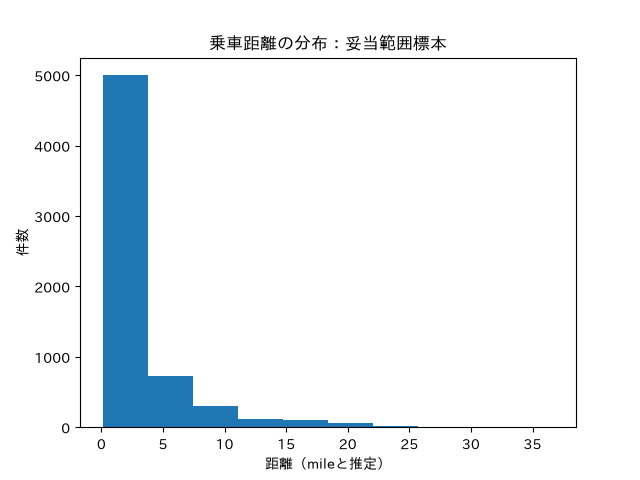

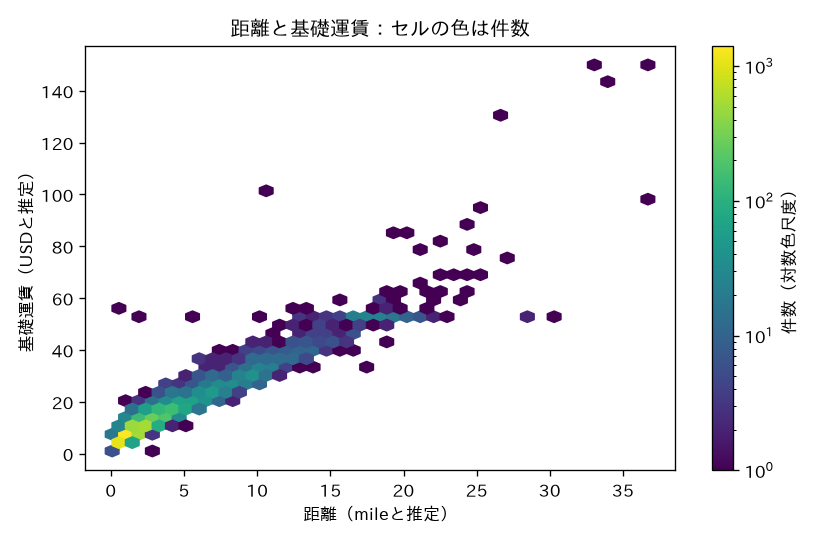

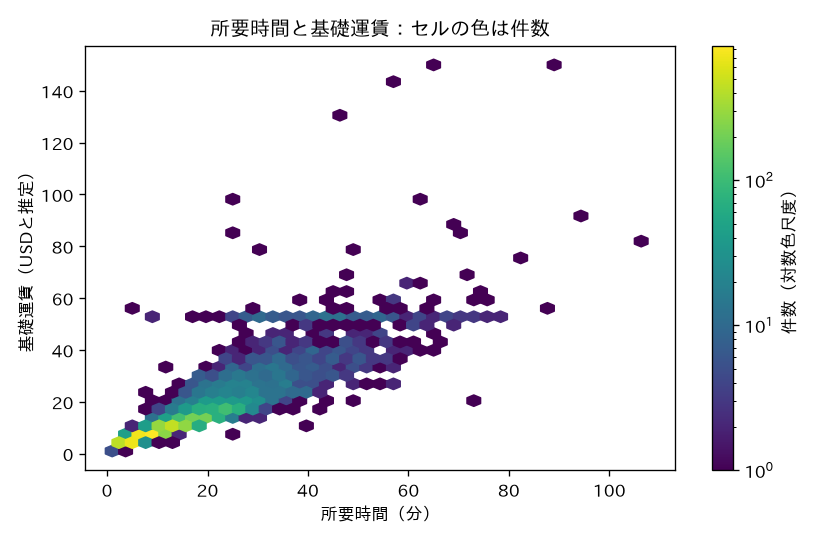

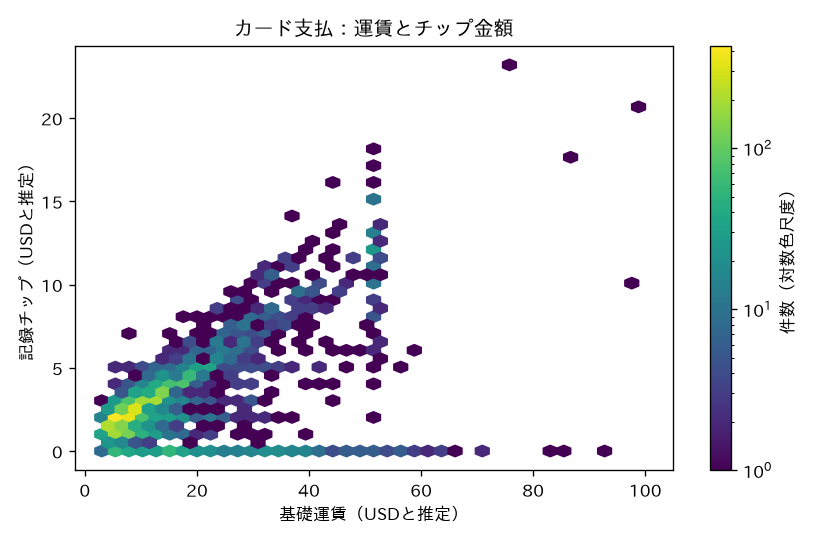

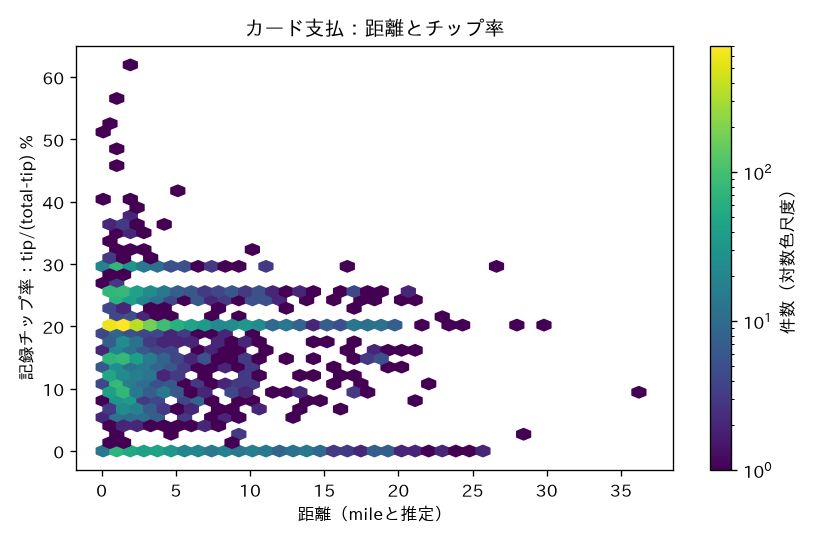

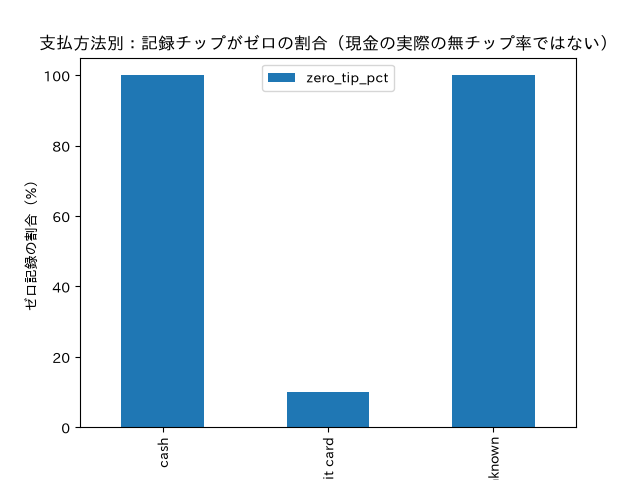

In [6]:
begin_execution('initial_charts')
from ai_data_scientist import visualization
import matplotlib.pyplot as plt
try:
    chart_warnings = []
    def emit_chart(png):
        output = visualization.build_image_output(png)
        display(output.data, raw=True)
    with warnings.catch_warnings(record=True) as observed:
        warnings.simplefilter('always')
        png = visualization.render_chart(core, kind='hist', x='distance', title='乗車距離の分布：妥当範囲標本', xlabel='距離（mileと推定）', ylabel='件数')
        emit_chart(png)
        for x,y,xlabel,ylabel,title in [
            ('distance','fare','距離（mileと推定）','基礎運賃（USDと推定）','距離と基礎運賃：セルの色は件数'),
            ('duration_min','fare','所要時間（分）','基礎運賃（USDと推定）','所要時間と基礎運賃：セルの色は件数'),
            ('fare','tip','基礎運賃（USDと推定）','記録チップ（USDと推定）','カード支払：運賃とチップ金額'),
            ('distance','tip_pretotal_pct','距離（mileと推定）','記録チップ率：tip/(total-tip) %','カード支払：距離とチップ率')]:
            part = card if y in ['tip','tip_pretotal_pct'] else core
            fig, ax = plt.subplots(figsize=(7,4.5))
            try:
                h = ax.hexbin(part[x], part[y], gridsize=40, mincnt=1, bins='log', cmap='viridis')
                fig.colorbar(h, ax=ax, label='件数（対数色尺度）')
                ax.set(title=title,xlabel=xlabel,ylabel=ylabel)
                fig.tight_layout()
                buf = io.BytesIO()
                fig.savefig(buf,format='png',dpi=120)
                emit_chart(buf.getvalue())
            finally:
                plt.close(fig)
        plot_payment = payment_summary.reset_index().fillna({'payment': 'unknown'})
        emit_chart(visualization.render_chart(plot_payment, kind='bar', x='payment', y='zero_tip_pct',
                   title='支払方法別：記録チップがゼロの割合（現金の実際の無チップ率ではない）', xlabel='支払方法', ylabel='ゼロ記録の割合（%）'))
        chart_warnings = [str(w.message) for w in observed if 'Glyph' in str(w.message)]
    print('glyph_warning_log=', chart_warnings)
    if chart_warnings:
        raise RuntimeError('図表の文字欠落を検出')
    print('図の選定: 重なりが多い連続値はhexbin、歪みは分布、支払経路は棒グラフ。全体傾向は表の相関と併読。外れ値を含む範囲はEDA表に残す。')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    end_execution('initial_charts')


# 初回結果の根拠出力

以降のInsightに引用する数値はprintの転記でなく、実行済みMIME出力から抽出する。

In [7]:
begin_execution('initial_evidence')
try:
    initial_evidence = {'n_raw': len(raw), 'n_core': len(core), 'n_card_core': len(card),
         'pickup_min': str(df.pickup.min()), 'pickup_max': str(df.pickup.max()),
         'distance_fare_pearson': float(core.distance.corr(core.fare)),
         'duration_fare_pearson': float(core.duration_min.corr(core.fare)),
         'distance_duration_pearson': float(core.distance.corr(core.duration_min)),
         'card_fare_tip_pearson': float(card.fare.corr(card.tip)),
         'card_distance_tiprate_spearman': float(card.distance.corr(card.tip_pretotal_pct,method='spearman')),
         'card_median_tip_pretotal_pct': float(card.tip_pretotal_pct.median()),
         'cash_n': int(payment_summary.loc['cash','n']), 'cash_zero_tip_pct': float(payment_summary.loc['cash','zero_tip_pct']),
         'distance_zero': zero_counts['distance_zero'], 'duration_nonpositive': zero_counts['duration_nonpositive'],
         'speed_gt80': int(df.speed_mph.gt(80).sum()), 'passengers_zero': int(df.passengers.eq(0).sum()),
         'payment_missing': int(df.payment.isna().sum()), 'excluded_primary': len(base)-len(core)}
    display({'text/plain': json.dumps(initial_evidence, ensure_ascii=False, indent=2)}, raw=True)
finally:
    end_execution('initial_evidence')


{
  "n_raw": 6433,
  "n_core": 6349,
  "n_card_core": 4538,
  "pickup_min": "2019-02-28 23:29:03",
  "pickup_max": "2019-03-31 23:43:45",
  "distance_fare_pearson": 0.9604533970991638,
  "duration_fare_pearson": 0.8885126070938131,
  "distance_duration_pearson": 0.8236186820478694,
  "card_fare_tip_pearson": 0.595781638135122,
  "card_distance_tiprate_spearman": -0.12008326099427512,
  "card_median_tip_pretotal_pct": 19.976815728038098,
  "cash_n": 1812,
  "cash_zero_tip_pct": 100.0,
  "distance_zero": 51,
  "duration_nonpositive": 6,
  "speed_gt80": 11,
  "passengers_zero": 96,
  "payment_missing": 44,
  "excluded_primary": 84
}

# 反復依頼履歴

## 反復1：分母と記録経路

### 追加依頼文（原文）
カード支払では距離帯が上がるとtip/fareの中央値が約32%から約20%へ下がっていますが、tip/(total-tip)は約20%のままです。この違いが追加料金を含む分母の選び方とゼロチップの混在で説明できるか、同一乗車の二つのチップ率、金額内訳の残差、ゼロ記録率、正のチップのみ、車種別を比較してください。日単位の再標本化で短距離と長距離のチップ率差も確認し、顧客が長距離でチップを渋るという解釈が妥当かを検討してください。

### 選定理由
初回の距離帯別表（統計セル）で二種類の率の傾向が異なる。分母を区別しないと「距離が長いほどチップ率が下がる」という実質的に誤った結論になる。日単位bootstrapは500回、seed=23。短距離<=1と長距離>10（mileと推定）を比較する。

In [8]:
begin_execution('iteration_1_denominator_recording')
try:
    card1 = card.copy()
    card1['unitemized_fare_pct'] = 100 * card1.unitemized_amount / card1.fare
    card1['zero_tip'] = card1.tip.eq(0)
    iter1_bins = card1.groupby('distance_bin', observed=True).agg(n=('tip','size'),
        zero_tip_pct=('zero_tip',lambda s:100*s.mean()), median_tip_fare_pct=('tip_fare_pct','median'),
        median_tip_pretotal_pct=('tip_pretotal_pct','median'), median_unitemized=('unitemized_amount','median'),
        median_unitemized_fare_pct=('unitemized_fare_pct','median'))
    display(iter1_bins)
    positive_bins = card1.loc[card1.tip.gt(0)].groupby('distance_bin', observed=True).agg(n=('tip','size'),
        tip_fare_pct=('tip_fare_pct','median'),tip_pretotal_pct=('tip_pretotal_pct','median'))
    display(positive_bins)
    iter1_color = card1.groupby('color').agg(n=('tip','size'), zero_tip_pct=('zero_tip',lambda s:100*s.mean()),
         median_tiprate=('tip_pretotal_pct','median'), rho_distance_rate=('distance',lambda s: s.corr(card1.loc[s.index,'tip_pretotal_pct'], method='spearman')))
    display(iter1_color)
    display(df.unitemized_amount.round(2).value_counts().head(15).rename_axis('total-fare-tip-tolls').to_frame('n'))
    print('金額整合: total < fare+tip+tollsの件数=', int(df.unitemized_amount.lt(-.02).sum()),
          '; fare+tip+tollsと一致しない件数=', int(df.unitemized_amount.abs().gt(.02).sum()))
    from scipy.stats import spearmanr
    rng = np.random.default_rng(23)
    card1['day'] = card1.pickup.dt.date
    days = sorted(card1.day.unique())
    bootstrap_diffs = []
    for _ in range(500):
        chosen = rng.choice(len(days), size=len(days), replace=True)
        sampled = pd.concat([card1.loc[card1.day.eq(days[i])] for i in chosen], ignore_index=True)
        short = sampled.loc[sampled.distance.le(1), 'tip_pretotal_pct']
        long = sampled.loc[sampled.distance.gt(10), 'tip_pretotal_pct']
        bootstrap_diffs.append(float(long.median() - short.median()))
    iter1_evidence = {'tip_fare_short_median': float(iter1_bins.iloc[0].median_tip_fare_pct),
          'tip_fare_long_median': float(iter1_bins.iloc[-1].median_tip_fare_pct),
          'tip_pretotal_short_median': float(iter1_bins.iloc[0].median_tip_pretotal_pct),
          'tip_pretotal_long_median': float(iter1_bins.iloc[-1].median_tip_pretotal_pct),
          'pretip_long_minus_short_pp': float(iter1_bins.iloc[-1].median_tip_pretotal_pct-iter1_bins.iloc[0].median_tip_pretotal_pct),
          'day_bootstrap_95_percentile_interval': np.quantile(bootstrap_diffs,[.025,.975]).tolist(),
          'n_bootstrap':500, 'n_days':len(days),
          'positive_tip_distance_rate_rho': float(card1.loc[card1.tip.gt(0),'distance'].corr(card1.loc[card1.tip.gt(0),'tip_pretotal_pct'],method='spearman')),
          'short_zero_pct': float(iter1_bins.iloc[0].zero_tip_pct), 'long_zero_pct': float(iter1_bins.iloc[-1].zero_tip_pct),
          'unitemized_nonzero_n': int(df.unitemized_amount.abs().gt(.02).sum())}
    display({'text/plain': json.dumps(iter1_evidence, ensure_ascii=False, indent=2)},raw=True)
    print('bootstrapは標本内の安定性であって、未知の抽出確率・全NYC母集団の信頼区間ではない。unitemized_amountを特定の税/追加料だと断定しない。')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    end_execution('iteration_1_denominator_recording')


金額整合: total < fare+tip+tollsの件数= 0 ; fare+tip+tollsと一致しない件数= 6411
bootstrapは標本内の安定性であって、未知の抽出確率・全NYC母集団の信頼区間ではない。unitemized_amountを特定の税/追加料だと断定しない。


,n,zero_tip_pct,median_tip_fare_pct,median_tip_pretotal_pct,median_unitemized,median_unitemized_fare_pct
distance_bin,,,,,,
"(0.0, 1.0]",1110,4.954955,31.818182,20.000000,3.30,63.333333
"(1.0, 2.0]",1445,4.013841,27.500000,20.000000,3.30,42.222222
"(2.0, 5.0]",1222,10.720131,24.551724,20.000000,3.55,25.384615
"(5.0, 10.0]",436,21.559633,22.251462,19.959472,3.30,12.941176
"(10.0, inf]",325,30.769231,20.480769,19.973369,3.30,6.346154


,n,tip_fare_pct,tip_pretotal_pct
distance_bin,,,
"(0.0, 1.0]",1055,32.000000,20.000000
"(1.0, 2.0]",1387,27.764706,20.000000
"(2.0, 5.0]",1091,25.000000,20.000000
"(5.0, 10.0]",342,23.098639,19.994492
"(10.0, inf]",225,23.461538,19.995881


,n,zero_tip_pct,median_tiprate,rho_distance_rate
color,,,,
green,561,45.811052,9.836066,-0.444522
yellow,3977,4.551169,19.996725,-0.040132


,n
total-fare-tip-tolls,
3.30,2625
3.80,1510
4.30,838
0.80,629
1.30,333
1.80,236
0.50,75
3.55,66
7.80,27


{
  "tip_fare_short_median": 31.818181818181817,
  "tip_fare_long_median": 20.48076923076923,
  "tip_pretotal_short_median": 20.0,
  "tip_pretotal_long_median": 19.973368841544605,
  "pretip_long_minus_short_pp": -0.026631158455394655,
  "day_bootstrap_95_percentile_interval": [
    -5.006830601092895,
    0.048236804881436945
  ],
  "n_bootstrap": 500,
  "n_days": 31,
  "positive_tip_distance_rate_rho": -0.006700029416283493,
  "short_zero_pct": 4.954954954954955,
  "long_zero_pct": 30.76923076923077,
  "unitemized_nonzero_n": 6411
}

# 反復1の読み直しと限界

分母をtotal-tipにすると短距離と長距離の中央値差は約-0.027ポイントまで縮むが、日単位bootstrap区間は約[-5.01,0.05]ポイントであり等価性は証明できない。正のtipだけの順位相関は約-0.007。車種で記録ゼロの割合が大きく異なるため、混合標本の弱い負相関を距離による顧客行動だとは解釈できない。証拠は反復1コードセルの率・車種表とJSON。追加料金の種類、現金チップ、抽出設計は未確認。

# 反復依頼履歴（続き）

## 反復2：構成差と距離・時間の重なり

### 追加依頼文（原文）
追加分析でカード支払のゼロチップ記録率がgreen約46%、yellow約5%と大きく違いました。長距離ほど記録ゼロが増える傾向が車種や出発地区の構成差だけで生じていないか、車種×距離帯の件数とゼロ記録率、車種・地区を調整した順位残差相関を比較してください。また距離と所要時間が強く関連しているため、運賃との関係は両者を同時に入れた記述的回帰と52ドル運賃を除く比較で確認し、係数を因果効果や運賃表と解釈しないでください。

### 選定理由
反復1の車種表は記録率の大きな混合差を示す。初回密度図にはfare=52の帯があり、距離と所要時間を別々に相関するだけでは「時間と運賃の関連」が距離の代理でないか区別できない。両方を記述モデルとして確認する。

In [9]:
begin_execution('iteration_2_composition_partial')
try:
    iter2_groups = card1.groupby(['color','distance_bin'], observed=True).agg(n=('tip','size'),
         zero_tip_pct=('zero_tip',lambda s:100*s.mean()), median_tiprate=('tip_pretotal_pct','median'))
    display(iter2_groups)
    display(card1.groupby(['color','pickup_borough'],dropna=False).agg(n=('tip','size'),zero_tip_pct=('zero_tip',lambda s:100*s.mean())))
    controls = pd.get_dummies(card1[['color','pickup_borough']].fillna('unknown'),drop_first=True,dtype=float)
    Xc = np.column_stack([np.ones(len(card1)),controls.to_numpy()])
    rank_x = card1.distance.rank().to_numpy()
    rank_y = card1.tip_pretotal_pct.rank().to_numpy()
    rx = rank_x-Xc@np.linalg.lstsq(Xc,rank_x,rcond=None)[0]
    ry = rank_y-Xc@np.linalg.lstsq(Xc,rank_y,rcond=None)[0]
    adjusted_rank_rho = float(np.corrcoef(rx,ry)[0,1])
    def fare_fit(part):
        x = np.column_stack([np.ones(len(part)),part[['distance','duration_min']].to_numpy()])
        y = part.fare.to_numpy()
        b = np.linalg.lstsq(x,y,rcond=None)[0]
        residual = y-x@b
        r2 = 1-float(np.square(residual).sum()/np.square(y-y.mean()).sum())
        return {'n':len(part),'intercept':float(b[0]),'distance_coef':float(b[1]),'minute_coef':float(b[2]),'r2':r2,
                'predictor_vif':1/(1-float(part.distance.corr(part.duration_min))**2)}
    iter2_fits = pd.DataFrame([{'subset':name,**fare_fit(part)} for name,part in [
        ('primary_all',core),('primary_yellow',core.loc[core.color.eq('yellow')]),
        ('primary_green',core.loc[core.color.eq('green')]),('excluding_fare52',core.loc[~np.isclose(core.fare,52)])]])
    display(iter2_fits)
    x_distance = np.column_stack([np.ones(len(core)),core.distance.to_numpy()])
    rt = core.duration_min.to_numpy()-x_distance@np.linalg.lstsq(x_distance,core.duration_min.to_numpy(),rcond=None)[0]
    rf = core.fare.to_numpy()-x_distance@np.linalg.lstsq(x_distance,core.fare.to_numpy(),rcond=None)[0]
    partial_time_fare = float(np.corrcoef(rt,rf)[0,1])
    rng2 = np.random.default_rng(2302)
    core_days = sorted(core.pickup.dt.date.unique())
    day_groups = [core.loc[core.pickup.dt.date.eq(day)] for day in core_days]
    bootstrap_coefs = []
    for _ in range(300):
        sampled = pd.concat([day_groups[i] for i in rng2.choice(len(core_days),len(core_days),replace=True)],ignore_index=True)
        fit = fare_fit(sampled)
        bootstrap_coefs.append([fit['distance_coef'],fit['minute_coef']])
    coef_interval = np.quantile(bootstrap_coefs,[.025,.975],axis=0)
    iter2_evidence = {'unadjusted_rank_rho':float(card1.distance.corr(card1.tip_pretotal_pct,method='spearman')),
          'color_borough_adjusted_rank_rho':adjusted_rank_rho,
          'yellow_zero_tip_pct':float(iter1_color.loc['yellow','zero_tip_pct']),
          'green_zero_tip_pct':float(iter1_color.loc['green','zero_tip_pct']),
          'yellow_distance_tiprate_rho':float(iter1_color.loc['yellow','rho_distance_rate']),
          'green_distance_tiprate_rho':float(iter1_color.loc['green','rho_distance_rate']),
          'fare_distance_coef':float(iter2_fits.iloc[0].distance_coef), 'fare_minute_coef':float(iter2_fits.iloc[0].minute_coef),
          'fare_r2':float(iter2_fits.iloc[0].r2), 'duration_fare_partial_r':partial_time_fare,
          'coef_day_bootstrap_95_percentile_intervals':coef_interval.T.tolist(),
          'fare52_n':int(np.isclose(core.fare,52).sum()),
          'exclude52_minute_coef':float(iter2_fits.iloc[-1].minute_coef)}
    display({'text/plain':json.dumps(iter2_evidence,ensure_ascii=False,indent=2)},raw=True)
    print('52ドルの帯は定額運賃の可能性にすぎず、rate_codeや空港情報で確認していない。線形OLSは記述モデルで、料金の距離/時間への課金方式、渋滞・運転者・顧客の因果効果は識別しない。')
    print('出発地区・車種を調整した順位残差相関は通常の単純Spearmanではなく、順位をダミー変数へ線形射影した後のPearson。時刻・行先・顧客構成など未調整の限界がある。')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    end_execution('iteration_2_composition_partial')


52ドルの帯は定額運賃の可能性にすぎず、rate_codeや空港情報で確認していない。線形OLSは記述モデルで、料金の距離/時間への課金方式、渋滞・運転者・顧客の因果効果は識別しない。
出発地区・車種を調整した順位残差相関は通常の単純Spearmanではなく、順位をダミー変数へ線形射影した後のPearson。時刻・行先・顧客構成など未調整の限界がある。


n  zero_tip_pct  median_tiprate
color  distance_bin                                    
green  (0.0, 1.0]      93     21.505376       20.000000
       (1.0, 2.0]     136     19.852941       20.000000
       (2.0, 5.0]     177     53.672316        0.000000
       (5.0, 10.0]     88     60.227273        0.000000
       (10.0, inf]     67     92.537313        0.000000
yellow (0.0, 1.0]    1017      3.441495       20.000000
       (1.0, 2.0]    1309      2.368220       20.000000
       (2.0, 5.0]    1045      3.444976       20.000000
       (5.0, 10.0]    348     11.781609       19.969395
       (10.0, inf]    258     14.728682       19.994124

n  zero_tip_pct
color  pickup_borough                    
green  Bronx             61     91.803279
       Brooklyn         211     53.080569
       Manhattan        154     19.480519
       Queens           135     43.703704
yellow Bronx             11    100.000000
       Brooklyn          45     37.777778
       Manhattan       3672      3.703704
       Queens           238      7.142857
       NaN               11      0.000000

,subset,n,intercept,distance_coef,minute_coef,r2,predictor_vif
0,primary_all,6349,2.417148,2.080655,0.293361,0.952004,3.108947
1,primary_yellow,5399,2.404180,2.069021,0.299505,0.954930,2.983598
2,primary_green,950,2.351345,2.144762,0.269325,0.939784,3.934011
3,excluding_fare52,6224,2.172772,2.148212,0.299318,0.953289,2.937197


{
  "unadjusted_rank_rho": -0.12008326099427512,
  "color_borough_adjusted_rank_rho": -0.06754760821721298,
  "yellow_zero_tip_pct": 4.551169223032437,
  "green_zero_tip_pct": 45.811051693404636,
  "yellow_distance_tiprate_rho": -0.040131610180542766,
  "green_distance_tiprate_rho": -0.4445218292230726,
  "fare_distance_coef": 2.0806552264604137,
  "fare_minute_coef": 0.2933606199410974,
  "fare_r2": 0.9520040942027725,
  "duration_fare_partial_r": 0.6171967383011033,
  "coef_day_bootstrap_95_percentile_intervals": [
    [
      1.93696454116824,
      2.2227426393548373
    ],
    [
      0.26559266448272306,
      0.31947654742826964
    ]
  ],
  "fare52_n": 125,
  "exclude52_minute_coef": 0.29931761163626586
}

glyph_warning_log= []
各群のnは反復2表を参照。特にgreen長距離の小標本を過剰解釈しない。


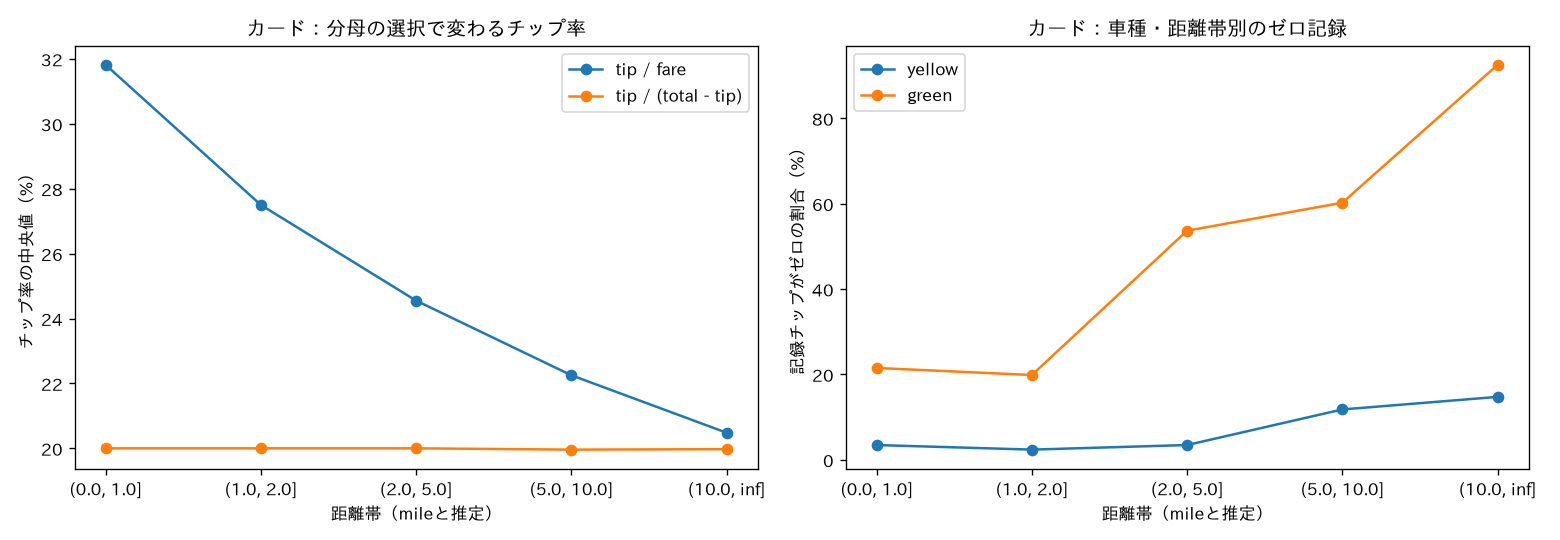

In [10]:
begin_execution('iteration_2_charts')
try:
    with warnings.catch_warnings(record=True) as observed:
        warnings.simplefilter('always')
        fig,axes = plt.subplots(1,2,figsize=(13,4.5))
        try:
            labels = [str(b) for b in iter1_bins.index]
            axes[0].plot(labels,iter1_bins.median_tip_fare_pct,marker='o',label='tip / fare')
            axes[0].plot(labels,iter1_bins.median_tip_pretotal_pct,marker='o',label='tip / (total - tip)')
            axes[0].set(title='カード：分母の選択で変わるチップ率',xlabel='距離帯（mileと推定）',ylabel='チップ率の中央値（%）')
            axes[0].legend()
            for color in ['yellow','green']:
                group = iter2_groups.loc[color].reindex(iter1_bins.index)
                axes[1].plot(labels,group.zero_tip_pct,marker='o',label=color)
            axes[1].set(title='カード：車種・距離帯別のゼロ記録',xlabel='距離帯（mileと推定）',ylabel='記録チップがゼロの割合（%）')
            axes[1].legend()
            fig.tight_layout()
            buf = io.BytesIO()
            fig.savefig(buf,format='png',dpi=120)
            emit_chart(buf.getvalue())
        finally:
            plt.close(fig)
        glyphs = [str(w.message) for w in observed if 'Glyph' in str(w.message)]
    print('glyph_warning_log=',glyphs)
    if glyphs:
        raise RuntimeError('図表の文字欠落')
    print('各群のnは反復2表を参照。特にgreen長距離の小標本を過剰解釈しない。')
finally:
    end_execution('iteration_2_charts')


# 反復2の読み直しと限界

車種・地区を調整した順位残差相関は約-0.068に弱まる。yellowの距離とチップ率の相関は約-0.040、greenでは約-0.445で、ゼロ記録の混合構成が重要。ただしyellowでも長距離のゼロ記録率は高く、構成差だけで全て説明できるとはいわない。距離調整後の時間と運賃の部分相関は約0.617、記述的時間係数は約0.293、fare=52を除いても約0.299。証拠は反復2の層別表・回帰表・JSONと比較図。運賃規則や顧客行動を識別したものではない。残る検証可能な点は除外閾値と高額乗車への依存。

# 反復依頼履歴（続き）

## 反復3：閾値・高額乗車・構成の感度

### 追加依頼文（原文）
距離と時間の運賃係数は正でしたが、84件の除外や高額乗車に依存していないか確認してください。所要時間の下限0.5・1・2分、速度上限40・60・80mph、距離・運賃の上位1%を残す／除く18仕様で、距離と運賃の相関、時間係数、カードの運賃とtip金額の相関、チップ率中央値と距離との順位相関を再計算してください。さらにyellow/green/混合とゼロtipを残す／除く6仕様でチップ率を比較し、SensitivityPlanの判定と数値範囲を示してください。安定しない結論は安定しないままとし、追加のデータなしでは解決しない限界を整理してください。

### 選定理由
初回の84件除外と高額乗車で相関が変わり得る。反復2の車種差を踏まえ、安定性を一つの「robust」にまとめず、数値ごとに評価する。18仕様×5指標の90評価＋構成6評価。20%許容は分析者の操作的基準として公開する。

In [11]:
begin_execution('iteration_3_sensitivity')
from ai_data_scientist import sensitivity
try:
    sensitivity_plan = sensitivity.SensitivityPlan(parameter_grid={'min_minutes':[1,.5,2], 'max_mph':[60,40,80], 'tail_quantile':[1,.99]},max_runs=18)
    def sensitivity_subset(min_minutes,max_mph,tail_quantile):
        mask = physical & base.duration_min.between(min_minutes,120) & base.speed_mph.le(max_mph)
        part = base.loc[mask].copy()
        if tail_quantile < 1:
            part = part.loc[part.distance.le(part.distance.quantile(tail_quantile)) & part.fare.le(part.fare.quantile(tail_quantile))]
        return part
    specification_metrics = []
    for spec in sensitivity_plan.specifications():
        part = sensitivity_subset(**spec)
        cc = part.loc[part.payment.eq('credit card')]
        specification_metrics.append({**spec,'n':len(part),'n_card':len(cc),
          'distance_fare_pearson':float(part.distance.corr(part.fare)),
          'fare_minute_coef':fare_fit(part)['minute_coef'],
          'card_fare_tip_pearson':float(cc.fare.corr(cc.tip)),
          'card_tiprate_median':float(cc.tip_pretotal_pct.median()),
          'card_distance_tiprate_spearman':float(cc.distance.corr(cc.tip_pretotal_pct,method='spearman'))})
    sensitivity_table = pd.DataFrame(specification_metrics)
    display(sensitivity_table)
    sensitivity_reports = {}
    metrics = ['distance_fare_pearson','fare_minute_coef','card_fare_tip_pearson','card_tiprate_median','card_distance_tiprate_spearman']
    def spec_value(metric, min_minutes,max_mph,tail_quantile):
        matching = sensitivity_table.loc[sensitivity_table.min_minutes.eq(min_minutes)&sensitivity_table.max_mph.eq(max_mph)&sensitivity_table.tail_quantile.eq(tail_quantile),metric]
        if len(matching)!=1:
            raise ValueError('Sensitivity specification does not resolve uniquely')
        return float(matching.iloc[0])
    for metric in metrics:
        sensitivity_reports[metric] = sensitivity.run_sensitivity(sensitivity_plan,lambda metric=metric,**spec:spec_value(metric,**spec),stability_tolerance=.2)
    sensitivity_summary = pd.DataFrame([{'metric':metric,'stable':report.stable,'max_relative_deviation':report.max_relative_deviation,
        'baseline':report.baseline_value,'min':float(sensitivity_table[metric].min()),'max':float(sensitivity_table[metric].max())}
        for metric,report in sensitivity_reports.items()])
    display(sensitivity_summary)
    composition_plan = sensitivity.SensitivityPlan(parameter_grid={'color':['all','yellow','green'],'positive_tip_only':[False,True]},max_runs=6)
    composition_metrics = []
    def composition_subset(color,positive_tip_only):
        part = card if color=='all' else card.loc[card.color.eq(color)]
        if positive_tip_only:
            part = part.loc[part.tip.gt(0)]
        return part
    for spec in composition_plan.specifications():
        part = composition_subset(**spec)
        composition_metrics.append({**spec,'n':len(part),'median_tiprate':float(part.tip_pretotal_pct.median()),
             'rho_distance_rate':float(part.distance.corr(part.tip_pretotal_pct,method='spearman'))})
    composition_table = pd.DataFrame(composition_metrics)
    display(composition_table)
    composition_report = sensitivity.run_sensitivity(composition_plan,lambda **spec:float(composition_subset(**spec).tip_pretotal_pct.median()),stability_tolerance=.2)
    revised_assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target':'取得ファイル限定の関連。フィルタ感度を検証済み'},causal_scope='associational',
        sampling={'n':len(raw),'seed':23,'method':'全行探索＋明示的除外、日単位bootstrap'},
        assumptions=tuple(analysis_assumptions.Assumption(a.id,a.statement,'tested' if a.id=='filter' else a.status,
            evidence_cell=None,impact_if_false=a.impact_if_false,conclusion_critical=a.conclusion_critical) for a in assumption_manifest.assumptions))
    revised_findings = analysis_assumptions.check_manifest(revised_assumptions)
    print('更新前提manifest:',json.dumps(asdict(revised_assumptions),ensure_ascii=False,default=str,indent=2))
    print('更新前提検査の全所見:',[asdict(f) for f in revised_findings])
    iter3_evidence = {'filter_runs':18,'scalar_report_evaluations':18*len(metrics),'composition_runs':6,
        'n_min':int(sensitivity_table.n.min()),'n_max':int(sensitivity_table.n.max()),
        'sensitivity':{metric:{'stable':r.stable,'max_relative_deviation':r.max_relative_deviation,
             'min':float(sensitivity_table[metric].min()),'max':float(sensitivity_table[metric].max())} for metric,r in sensitivity_reports.items()},
        'composition_tiprate_stable':composition_report.stable,'composition_tiprate_max_relative_deviation':composition_report.max_relative_deviation,
        'remaining_assumption_warnings':len(revised_findings)}
    display({'text/plain':json.dumps(iter3_evidence,ensure_ascii=False,indent=2)},raw=True)
    print('許容相対偏差20%は操作的基準。符号の一致や中央値の一致だけであらゆる解釈の頑健性を保証しない。車種差は異なる対象の比較であり測定経路の差もあり得る。未観測の現金tip・原列変換・抽出確率は追加の統計操作では識別できない。')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    end_execution('iteration_3_sensitivity')


更新前提manifest: {
  "analysis_scope": {
    "target": "取得ファイル限定の関連。フィルタ感度を検証済み"
  },
  "assumptions": [
    {
      "id": "units",
      "statement": "distanceはmile、金額はUSDである",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "絶対量と速度閾値の解釈が変わる",
      "conclusion_critical": true
    },
    {
      "id": "recorded-tip",
      "statement": "現金のtipゼロは無チップではなく記録経路の制約かもしれない",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "支払方法による顧客行動差の推論はできない",
      "conclusion_critical": true
    },
    {
      "id": "representative",
      "statement": "NYC全乗車を代表する",
      "status": "rejected",
      "evidence_cell": null,
      "impact_if_false": "母集団へ一般化しない",
      "conclusion_critical": false
    },
    {
      "id": "filter",
      "statement": "速度・所要時間の範囲は異常候補除外の操作的定義",
      "status": "tested",
      "evidence_cell": null,
      "impact_if_false": "後続感度分析で確認する",
      "conclusion_critical": true
    }
  ],
  "causal_scope": "associatio

,min_minutes,max_mph,tail_quantile,n,n_card,distance_fare_pearson,fare_minute_coef,card_fare_tip_pearson,card_tiprate_median,card_distance_tiprate_spearman
0,1.0,60,1.00,6349,4538,0.960453,0.293361,0.595782,19.976816,-0.120083
1,1.0,60,0.99,6272,4479,0.967425,0.313580,0.625728,19.980347,-0.109970
2,1.0,40,1.00,6332,4527,0.960189,0.305322,0.586189,19.976636,-0.120574
3,1.0,40,0.99,6256,4467,0.967069,0.320662,0.614152,19.980347,-0.109696
4,1.0,80,1.00,6349,4538,0.960453,0.293361,0.595782,19.976816,-0.120083
5,1.0,80,0.99,6272,4479,0.967425,0.313580,0.625728,19.980347,-0.109970
6,0.5,60,1.00,6361,4547,0.960458,0.293162,0.596226,19.976905,-0.119369
7,0.5,60,0.99,6284,4488,0.967411,0.313362,0.626176,19.980347,-0.109260
8,0.5,40,1.00,6344,4536,0.960193,0.305106,0.586651,19.976681,-0.119854
9,0.5,40,0.99,6268,4476,0.967055,0.320432,0.614624,19.980347,-0.108981


,metric,stable,max_relative_deviation,baseline,min,max
0,distance_fare_pearson,True,0.007259,0.960453,0.960041,0.967425
1,fare_minute_coef,True,0.093065,0.293361,0.292858,0.320662
2,card_fare_tip_pearson,True,0.051016,0.595782,0.584313,0.626176
3,card_tiprate_median,True,0.000177,19.976816,19.976636,19.980347
4,card_distance_tiprate_spearman,True,0.092456,-0.120083,-0.122275,-0.108981


,color,positive_tip_only,n,median_tiprate,rho_distance_rate
0,all,False,4538,19.976816,-0.120083
1,all,True,4100,20.000000,-0.006700
2,yellow,False,3977,19.996725,-0.040132
3,yellow,True,3796,20.000000,0.001830
4,green,False,561,9.836066,-0.444522
5,green,True,304,20.000000,-0.116530


{
  "filter_runs": 18,
  "scalar_report_evaluations": 90,
  "composition_runs": 6,
  "n_min": 6176,
  "n_max": 6361,
  "sensitivity": {
    "distance_fare_pearson": {
      "stable": true,
      "max_relative_deviation": 0.007258950130828589,
      "min": 0.9600413300141987,
      "max": 0.9674252804116915
    },
    "fare_minute_coef": {
      "stable": true,
      "max_relative_deviation": 0.09306481098638107,
      "min": 0.29285777495047177,
      "max": 0.3206621705867632
    },
    "card_fare_tip_pearson": {
      "stable": true,
      "max_relative_deviation": 0.051016264695793505,
      "min": 0.5843134023285144,
      "max": 0.6261761918871168
    },
    "card_tiprate_median": {
      "stable": true,
      "max_relative_deviation": 0.00017677849592773323,
      "min": 19.976635514018696,
      "max": 19.980347199475926
    },
    "card_distance_tiprate_spearman": {
      "stable": true,
      "max_relative_deviation": 0.09245556175660925,
      "min": -0.12227454378165652,
   

# 反復3の読み直し・停止判断

閾値・上位1%の18仕様で距離–運賃の相関は0.9600–0.9674、時間係数は0.2929–0.3207、カード運賃–tipの相関は0.5843–0.6262。いずれも20%許容でstable=True。一方、構成6仕様のチップ率中央値はstable=False、最大相対偏差約50.76%。証拠は反復3表・JSON。閾値に安定した混合標本の相関を、車種・記録方法を越えた普遍的関係だと解釈しない。

3回の反復を実行済み。残る実質的限界は現金tip未観測、greenの記録経路、抽出設計、列の意味・単位の完全な来歴であり、同じCSVの追加操作では解消できない。これ以上の価値ある同一標本内追加分析は見当たらず、最大3回で停止する。因果・母集団代表性・現在の運賃・等価性は主張しない。

# Jupytermind改善候補

## 候補1：実行済みstream出力がInsightの証拠として認識されない

- 分類：証拠エンジンの機能不足候補（MIME出力とstream出力の非対称）。
- 再現条件：初回統計セルでprintしたdistance_fare_pearsonの完全精度値を、実保存済みstreamからextract_cited_valueで抽出し、同じ実行番号と値をrecord_insightへ渡す。後続の診断セルを参照。
- 期待する挙動：実行済みNotebookに存在するstream.textも、MIME dataと同様に証拠照合対象になる、またはstream非対応を明示した公開契約になる。
- 実際の挙動：stream_contains_value=TrueなのにEvidenceMissingError。例外クラス・本文・該当実行番号・引用値は診断セルのJSONログに記録する。例外は診断のため具体的に捕捉し、分析失敗を成功扱いにしていない。
- 影響：print中心の実分析からInsightを記録できない。_find_evidence_cellがoutputs.dataだけを探索するためnotebook_auditの根拠解決にも影響する可能性がある。
- 回避策：同じ計算結果をIPython.displayでtext/plain MIMEとして出力し、保存済み出力から抽出・照合する。初回根拠セルと各反復JSONを採用した。証拠を偽造したり監査を抑制しない。
- 関係するセルとログ：初回統計セル、stream診断セル、初回根拠出力セル、Insight記録セル。metadata.stream_evidence_diagnostic、診断JSON、最終監査ログ。
- 切り分け：Kaggle API認証・検索・ダウンロードは成功し、Jupyter MCPは正しいstreamを保存している。Copilot CLI固有の表示切詰めやベンチマークランナーとは独立。実行コード・データを変えず証拠出力形式を変えると記録可能。ソフトウェア修正やIssue登録は今回の分析依頼の範囲外で行わない。

## 周辺環境・外部サービスの記録（Jupytermind不具合とは分類しない）
公式TLC辞書のHTTP取得に失敗しHTTPErrorを記録。意味の未確認は外部取得・短縮列来歴の制約でありJupytermindのバグではない。mcp_gatewayの実Pythonクライアントをホストが渡していないことは呼出し環境の接続制約であり、ローカル実行へ迂回しない。独立第二標本がないことはデータ範囲の制約。候補はstream証拠処理と、以下の書込み統合不足の2件。


## 候補2：実行中Notebookへのenqueue_writeで、そのセルの実行結果が保存されない

分類：Jupyter MCPとproject_managerの書込み統合不足候補。原因帰属は未確定であり、Jupytermind単独の不具合とは断定しない。

再現条件：対象セルの実行中、対象Notebook自身へenqueue_writeまたはrecord_insightで書込みを行う。初期版のstream診断セルとInsight記録セルで再現。期待は本文更新とセルのexecution_count・outputsが共に保存されること。実際はツールから実出力を得たのに、直後のnbformat読込とjupyter.read_cellでは2セルのexecution_count=None・outputs空で、事前監査のunexecuted_cell_indices=[25,28]となった。事前監査時にlifecycleはfailedを記録し、成功として引き渡していない。

影響：計算の実行と保存の不一致、監査失敗。回避策は対象セル内の自己書込みを排除し、セル完了後に同一カーネルを共有するJupyter MCP管理Notebookからpersist_insightsを呼ぶこと。本文はenqueue_write、証拠はrecord_insightを使用し、全コードを再実行して保存結果を再監査する。最終の診断・準備・監査セルは自己Notebookを書き換えない。

関係するセル・ログ：stream診断セル、Insight準備セル、最終監査セル、metadata.write_integration_incident、data/write_integration_incident.json、事前監査ログ。CLIの表示切詰めはこの現象ではなく、Kaggle APIは成功している。ベンチマークランナーも使っていない。Jupyter MCP側のNotebook再読込/保存タイミングとJupytermind側のファイル書込みの統合に絞られるが、各単体の欠陥はこの実験だけでは判定できない。


In [12]:
begin_execution('jupytermind_stream_evidence_diagnostic')
from ai_data_scientist import insight_engine
try:
    stored = nbformat.read(handle.notebook_path,as_version=4)
    stat_cell = next(c for c in stored.cells if c.cell_type=='code' and "begin_execution('initial_statistics')" in c.source)
    stream_text = ''.join(o.get('text','') for o in stat_cell.outputs if o.output_type=='stream')
    value = insight_engine.extract_cited_value({'output':stream_text},r'"distance_fare_pearson": ([0-9.]+)')
    diagnostics = {'name':'stream_evidence_not_supported', 'evidence_execution_count':stat_cell.execution_count,
                   'exact_cited_value':value,'stream_contains_value':value in stream_text}
    try:
        insight_engine.record_insight(handle,'診断専用：printによる実行済み証拠の受理確認',stat_cell.execution_count,value,'diagnostic',language='ja')
        diagnostics['actual']='accepted'
        write_notebook(lambda nb: setattr(nb,'cells',[c for c in nb.cells if not c.source.startswith('診断専用：')]))
    except insight_engine.EvidenceMissingError as exc:
        diagnostics['actual']='EvidenceMissingError'
        diagnostics['exception_message']=str(exc)
    display({'text/plain':json.dumps(diagnostics,ensure_ascii=False,indent=2)},raw=True)
    (data_dir/'stream_evidence_diagnostic.json').write_text(json.dumps(diagnostics,ensure_ascii=False,indent=2),encoding='utf-8')
finally:
    end_execution('jupytermind_stream_evidence_diagnostic')


{
  "name": "stream_evidence_not_supported",
  "evidence_execution_count": 5,
  "exact_cited_value": "0.9604533970991638",
  "stream_contains_value": true,
  "actual": "EvidenceMissingError",
  "exception_message": "Insight '診断専用：printによる実行済み証拠の受理確認' に根拠となる実行済みセル(execution_count=5)が見つからないため記録を保留しました。"
}

# 使用したJupytermindモジュール

直接import・直接呼び出したもののみ。Pandas/NumPy/SciPy/Matplotlib/nbformat/Kaggle/IPython/標準ライブラリはJupytermindではない。

| モジュール（ai_data_scientist配下） | 直接呼び出した関数・クラス | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | slug検証、固定保存先、データ保存先、直列化した本文・metadata・Insight書込み |
| language_router | detect_language | 日本語指示を検出 |
| lifecycle | register_run, mark_execution_start, mark_execution_end, mark_write_start, mark_write_end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行・書込み・キャンセル・終端状態を記録 |
| ingestion | SourceSpec, ingest | ステージ済みCSV読込・100000行予算の検査 |
| cleaning | clean_dataset | 重複と必須列欠損の影響確認（今回どちらも0行） |
| eda | explore | 型、非欠損件数、欠損、要約 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | ファイル同一性と意味の確度を分離。inferredは明示的にも列挙 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 因果範囲・抽出・単位・記録経路・フィルタ前提と未解決警告 |
| data_quality | detect_anomalies | スキーマの意味的範囲・欠損・カテゴリ検査 |
| stats_analysis | correlation | 日本語解釈付きPearson相関（p値を母集団推論へ使わない） |
| visualization | render_chart, build_image_output | 日本語軸の分布・支払別棒グラフと、全PNGのMIME出力 |
| insight_engine | extract_cited_value, record_insight, EvidenceMissingError | 実出力から引用値抽出、実行番号付きInsight、stream証拠拒否の再現 |
| sensitivity | SensitivityPlan, SensitivityPlan.specifications, run_sensitivity | 18仕様×5指標と構成6仕様の安定性 |
| notebook_audit | audit_notebook | 最終visual_audit=True監査 |

## 非適用・直接未使用
mcp_gateway.run_and_recordは使っていない。今回のホストにあるのはJupyter MCPのツール呼び出しで、カーネル内のMCPClient.executeを実装する実クライアントは渡されていない。ローカルexec・偽クライアント・REST/別プロセス実行へ置き換えず、全実行をJupyter MCPのexecute_cellに限定した。本文はenqueue_write、実行出力の保存はMCPサーバーの責務である。

validate_anomalies/dataset_validation.compare_datasetsは独立第二標本がないため未使用。同じSeabornデータの再配布を独立参照にしない。z-scoreのanomaly_detectionは歪んだ正値分布を真のエラーと混同しやすく、今回は意味的検査と分位点・閾値感度で代替。ML/NLP/DB/Excelは問い・形式に不要。visualization.record_chartはコードを実行せず実行済み番号を付けるため用いず、実際のMCP実行でPNGを保存した。dependency_pinsは間接利用も使用済みに数えない。


# 根拠付きInsight

直前までに保存された実行済みMIME出力から引用値を抽出する。再実行時は生成済みInsightを置換し、最新の実行番号へ結び直す。

自己書込みの保存競合を避けるため、このセルは関数準備のみ。Jupyter MCPによる対象セル実行の完了後、同一カーネルの管理セルでpersist_insightsを呼び、その後に最終監査セルを実行する。管理セルもNotebookに記録し、分析・API処理を端末へ迂回しない。

In [13]:
begin_execution('prepare_insight_writer')
from ai_data_scientist import insight_engine
def persist_insights():
    def remove_generated(nb):
        nb.cells = [c for c in nb.cells if not c.get('metadata',{}).get('generated_insight')]
    write_notebook(remove_generated)
    stored = nbformat.read(handle.notebook_path,as_version=4)
    stage_data = {}
    for cell in stored.cells:
        stage = cell.get('metadata',{}).get('analysis_stage')
        if stage not in ['initial_evidence','iteration1','iteration2','iteration3']:
            continue
        if cell.execution_count is None:
            raise RuntimeError('根拠セルが未実行: '+stage)
        texts = [o.get('data',{}).get('text/plain','') for o in cell.outputs if o.output_type in ['display_data','execute_result']]
        json_outputs = [text for text in texts if text.startswith('{')]
        if len(json_outputs)!=1:
            raise RuntimeError('根拠JSONを一意に特定できない: '+stage)
        stage_data[stage] = {'output':json_outputs[0], 'execution_count':cell.execution_count, 'values':json.loads(json_outputs[0])}
    e = stage_data['initial_evidence']['values']; a = stage_data['iteration1']['values']; b = stage_data['iteration2']['values']; s = stage_data['iteration3']['values']
    claims = [
        ('initial_evidence','n_raw',f"このファイルには{e['n_raw']:,}件・14列があり、乗車開始は{e['pickup_min']}から{e['pickup_max']}まで。全行を探索したが、正の距離・時間と操作的範囲で{e['excluded_primary']}件を除いた主分析は{e['n_core']:,}件、カード主分析は{e['n_card_core']:,}件。抽出設計が不明のためNYC全体へ一般化しない。" ,'descriptive'),
        ('initial_evidence','distance_fare_pearson',f"主分析で距離と基礎運賃のPearson相関は{e['distance_fare_pearson']:.4f}、所要時間と基礎運賃は{e['duration_fare_pearson']:.4f}、距離と時間は{e['distance_duration_pearson']:.4f}。これは同一標本内の関連で、距離mile・金額USDは未検証の推定。" ,'association'),
        ('initial_evidence','card_fare_tip_pearson',f"カード主分析では運賃と記録チップ金額のPearson相関は{e['card_fare_tip_pearson']:.4f}。チップ金額が増えることはチップ率が増えることと同じではなく、支払総額totalにtipを含めて相関する循環も避けた。" ,'association'),
        ('initial_evidence','cash_zero_tip_pct',f"現金支払{e['cash_n']:,}件の記録tipは{e['cash_zero_tip_pct']:.1f}%がゼロ。現金の実際のチップ額は観測されない可能性があり、「現金客はチップを払わない」やカードとの行動差を結論しない。記録経路は分析前提manifestでassumedとして残す。" ,'descriptive'),
        ('iteration1','pretip_long_minus_short_pp',f"カードの短距離<=1と長距離>10ではtip/fare中央値が{a['tip_fare_short_median']:.2f}%から{a['tip_fare_long_median']:.2f}%へ下がるが、tip/(total-tip)の中央値差は{a['pretip_long_minus_short_pp']:.4f}ポイント。日単位bootstrap区間は[{a['day_bootstrap_95_percentile_interval'][0]:.2f}, {a['day_bootstrap_95_percentile_interval'][1]:.2f}]ポイントであり等価性は証明できない。正のtipだけの距離・率の順位相関は{a['positive_tip_distance_rate_rho']:.4f}。分母の選び方とゼロ記録の混在を区別すべき。" ,'association'),
        ('iteration2','color_borough_adjusted_rank_rho',f"カードの距離とtip/(total-tip)の順位相関は{b['unadjusted_rank_rho']:.4f}で、車種・出発地区に線形射影した順位残差相関は{b['color_borough_adjusted_rank_rho']:.4f}に弱まる。記録ゼロはyellow {b['yellow_zero_tip_pct']:.2f}%、green {b['green_zero_tip_pct']:.2f}%。greenの大きな負相関を全NYC・全顧客へ一般化せず、記録方法・地区・顧客構成を未識別のままとする。" ,'association'),
        ('iteration2','fare_minute_coef',f"距離と所要時間を同時に入れた記述的OLSでは時間係数は{b['fare_minute_coef']:.4f}、距離調整後の時間・運賃の部分相関は{b['duration_fare_partial_r']:.4f}。fare=52の{b['fare52_n']}件を除いても時間係数は{b['exclude52_minute_coef']:.4f}。料金表や時間の因果効果ではなく、運賃構造の違いを含む標本内の関連。" ,'association'),
        ('iteration3','composition_tiprate_max_relative_deviation',f"18の閾値・上位1%仕様では5指標とも相対偏差20%の操作的基準を満たした（stable=True）。一方、車種とゼロtipの扱いを変えた6仕様の率中央値はstable={s['composition_tiprate_stable']}、最大相対偏差={s['composition_tiprate_max_relative_deviation']:.4f}。閾値に安定することと車種を越えて同じチップ率であることは別であり、単一の頑健なチップ率と結論しない。" ,'sensitivity')]
    insight_log=[]
    for stage,key,text,claim_type in claims:
        result = stage_data[stage]
        import re
        cited = insight_engine.extract_cited_value(result, r'"'+re.escape(key)+r'": ([^,\n]+)')
        lifecycle.mark_write_start(RUN_ID)
        log_phase('insight_write_start:'+stage+':'+key)
        try:
            insight_engine.record_insight(handle,text,result['execution_count'],cited,claim_type,language='ja')
            def tag(nb):
                nb.cells[-1].metadata['generated_insight']=True
            pm.enqueue_write(handle,tag)
        finally:
            lifecycle.mark_write_end(RUN_ID)
            log_phase('insight_write_end:'+stage+':'+key)
        insight_log.append({'stage':stage,'key':key,'execution_count':result['execution_count'],'cited_value':cited})
    def relocate_audit(nb):
        final_cells=[c for c in nb.cells if c.get('metadata',{}).get('analysis_stage')=='final_audit']
        nb.cells=[c for c in nb.cells if c.get('metadata',{}).get('analysis_stage')!='final_audit']+final_cells
        nb.metadata['run_id']=RUN_ID
        nb.metadata['provenance']=provenance
    write_notebook(relocate_audit)
    lifecycle.mark_write_start(RUN_ID)
    log_phase('artifact_write_start')
    try:
        (data_dir/'data_definition_manifest.json').write_text(json.dumps(asdict(definition_manifest),ensure_ascii=False,default=str,indent=2),encoding='utf-8')
        (data_dir/'analysis_assumptions_manifest.json').write_text(json.dumps(asdict(revised_assumptions),ensure_ascii=False,default=str,indent=2),encoding='utf-8')
        (data_dir/'sensitivity_report.json').write_text(json.dumps(iter3_evidence,ensure_ascii=False,indent=2),encoding='utf-8')
        sensitivity_table.to_csv(data_dir/'sensitivity_specifications.csv',index=False)
        corr_table.to_csv(data_dir/'correlations.csv',index=False)
    finally:
        lifecycle.mark_write_end(RUN_ID)
        log_phase('artifact_write_end')
    display(pd.DataFrame(insight_log))
end_execution('prepare_insight_writer')
print('persist_insights関数を準備。対象Notebookへの書込みはセル実行が終了した後、同一カーネルのJupyter MCP管理セルから行う。')


persist_insights関数を準備。対象Notebookへの書込みはセル実行が終了した後、同一カーネルのJupyter MCP管理セルから行う。


# 再実行と最終監査

Jupyter MCPでカーネルを再起動し、全コードセルを上から順に実行する。Kaggle認証・検索・再取得とSHA-256一致を含む。Insight準備セルの終了後だけ管理Notebookでpersist_insightsを呼び、最新出力へ根拠番号を更新する。最終セルはvisual_audit=Trueで監査してcompletedを記録する。全セルの出力保存後にも読み取り監査を行い、metadataへ記録する。

このファイルには6,433件・14列があり、乗車開始は2019-02-28 23:29:03から2019-03-31 23:43:45まで。全行を探索したが、正の距離・時間と操作的範囲で84件を除いた主分析は6,349件、カード主分析は4,538件。抽出設計が不明のためNYC全体へ一般化しない。

```evidence
{"execution_count":7,"cited_value":"6433","claim_type":"descriptive"}
```

主分析で距離と基礎運賃のPearson相関は0.9605、所要時間と基礎運賃は0.8885、距離と時間は0.8236。これは同一標本内の関連で、距離mile・金額USDは未検証の推定。

```evidence
{"execution_count":7,"cited_value":"0.9604533970991638","claim_type":"association"}
```

カード主分析では運賃と記録チップ金額のPearson相関は0.5958。チップ金額が増えることはチップ率が増えることと同じではなく、支払総額totalにtipを含めて相関する循環も避けた。

```evidence
{"execution_count":7,"cited_value":"0.595781638135122","claim_type":"association"}
```

現金支払1,812件の記録tipは100.0%がゼロ。現金の実際のチップ額は観測されない可能性があり、「現金客はチップを払わない」やカードとの行動差を結論しない。記録経路は分析前提manifestでassumedとして残す。

```evidence
{"execution_count":7,"cited_value":"100.0","claim_type":"descriptive"}
```

カードの短距離<=1と長距離>10ではtip/fare中央値が31.82%から20.48%へ下がるが、tip/(total-tip)の中央値差は-0.0266ポイント。日単位bootstrap区間は[-5.01, 0.05]ポイントであり等価性は証明できない。正のtipだけの距離・率の順位相関は-0.0067。分母の選び方とゼロ記録の混在を区別すべき。

```evidence
{"execution_count":8,"cited_value":"-0.026631158455394655","claim_type":"association"}
```

カードの距離とtip/(total-tip)の順位相関は-0.1201で、車種・出発地区に線形射影した順位残差相関は-0.0675に弱まる。記録ゼロはyellow 4.55%、green 45.81%。greenの大きな負相関を全NYC・全顧客へ一般化せず、記録方法・地区・顧客構成を未識別のままとする。

```evidence
{"execution_count":9,"cited_value":"-0.06754760821721298","claim_type":"association"}
```

距離と所要時間を同時に入れた記述的OLSでは時間係数は0.2934、距離調整後の時間・運賃の部分相関は0.6172。fare=52の125件を除いても時間係数は0.2993。料金表や時間の因果効果ではなく、運賃構造の違いを含む標本内の関連。

```evidence
{"execution_count":9,"cited_value":"0.2933606199410974","claim_type":"association"}
```

18の閾値・上位1%仕様では5指標とも相対偏差20%の操作的基準を満たした（stable=True）。一方、車種とゼロtipの扱いを変えた6仕様の率中央値はstable=False、最大相対偏差=0.5076。閾値に安定することと車種を越えて同じチップ率であることは別であり、単一の頑健なチップ率と結論しない。

```evidence
{"execution_count":11,"cited_value":"0.507625954622725","claim_type":"sensitivity"}
```

In [15]:
begin_execution('final_notebook_audit')
from ai_data_scientist import notebook_audit
try:
    report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    audit_record = {**asdict(report),'ok':report.ok,'visual_audit':True,'audited_at_utc':datetime.now(timezone.utc).isoformat()}
    display({'text/plain':json.dumps(audit_record,ensure_ascii=False,indent=2)},raw=True)
    if not report.ok:
        raise RuntimeError('Notebook監査に未解決errorあり')
    if report.visual_findings:
        raise RuntimeError('図表監査に未解決所見あり')
    if any(f.severity=='error' for f in revised_findings):
        raise RuntimeError('分析前提manifestにerrorあり')
    print('残る前提warning:',[asdict(f) for f in revised_findings])
    print('意味のinferred/unknownは残り、計算成功と意味検証を混同しない。')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    end_execution('final_notebook_audit')
lifecycle.mark_completed(RUN_ID)
status = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
if status.state!='completed' or status.active_cell_executions or status.pending_notebook_writes or status.locks_held:
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('Lifecycleが正常な終端・静止状態でない')
(data_dir/'notebook_audit.json').write_text(json.dumps(audit_record,ensure_ascii=False,indent=2),encoding='utf-8')
(data_dir/'lifecycle.json').write_text(json.dumps({'status':asdict(status),'phase_log':phase_log},ensure_ascii=False,indent=2),encoding='utf-8')
display({'text/plain':json.dumps({'lifecycle':asdict(status),'phase_log':phase_log},ensure_ascii=False,indent=2)},raw=True)


意味のinferred/unknownは残り、計算成功と意味検証を混同しない。


{
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-23-taxis/notebooks/kaggle-v020-kaggle-exp-23-taxis.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 14,
  "executed_code_cell_count": 13,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    11,
    19
  ],
  "insight_cell_count": 8,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 38
    }
  ],
  "visual_findings": [],
  "ok": true,
  "visual_audit": true,
  "audited_at_utc": "2026-10-01T20:06:27.257386+00:00"
}

{
  "lifecycle": {
    "run_id": "v020-exp-23",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-23-taxis/notebooks/kaggle-v020-kaggle-exp-23-taxis.ipynb",
    "reason": null
  },
  "phase_log": [
    {
      "time_utc": "2026-10-01T20:04:58.769074+00:00",
      "event": "execution_start:kaggle_search"
    },
    {
      "time_utc": "2026-10-01T20:05:06.707660+00:00",
      "event": "execution_end:kaggle_search"
    },
    {
      "time_utc": "2026-10-01T20:05:09.903806+00:00",
      "event": "execution_start:kaggle_download"
    },
    {
      "time_utc": "2026-10-01T20:05:11.648525+00:00",
      "event": "execution_end:kaggle_download"
    },
    {
      "time_utc": "2026-10-01T20:05:15.652788+00:00",
      "event": "execution_start:definitions_quality_eda"
    },
    {
      "time_utc": "2026-10-01T20:05:16.053256+00:00",
